<a href="https://colab.research.google.com/github/FOFM030711/Caminata-aleatoria-1D/blob/main/serpientesy_escaleras.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 1. Título del Problema y Contexto


**MATRIZ FUNDAMENTAL**

*SERPIENTES Y ESCALERAS*

Este juego de serpientes y escaleras tiene como objetivo calcular el número promedio de tiradas necesarias para terminar el juego.

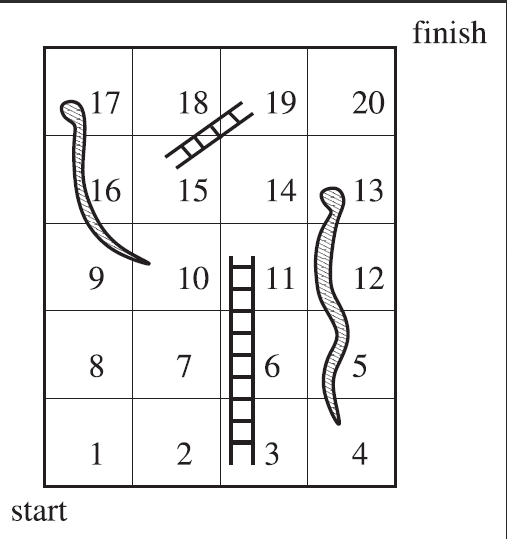

Resolver analíticamente y por simulación en un cuaderno de Jupyter Notebook.

**¿Cuál es el número promedio de tiradas necesarias para terminar el juego de serpientes y escaleras en el tablero de la imagen adjunta?**

Importamos las librerias necesarias :

In [17]:
import numpy as np
from sympy import Matrix , init_printing, Rational
import sympy as sp
import networkx as nx
import matplotlib.pyplot as plt

init_printing() # Enable pretty printing for SymPy objects

##  Definición de la Matriz de Transición

In [20]:
def matriz_transicion_serpientes_escaleras():
    # Configuración
    n = 20
    dado = 6

    # Saltos especiales
    salto = list(range(n + 1))  # índice 0 no se usa
    # Escaleras
    salto[3] = 11
    salto[15] = 19
    # Serpientes
    salto[13] = 5
    salto[17] = 7

    # Crear matriz usando sympy.Matrix
    P = sp.Matrix.zeros(n, n)

    for i in range(1, n + 1):
        if i == n:  # Casilla 20 absorbente
            P[i-1, i-1] = 1
            continue

        for k in range(1, dado + 1):
            # Posición después del dado
            pos = i + k
            if pos > n:
                pos = i  # Se queda si se pasa
            # Aplicar salto si existe
            pos_final = salto[pos]
            P[i-1, pos_final-1] += sp.Rational(1, dado) # Usar Rational para fracciones exactas

    return P

In [24]:
P = matriz_transicion_serpientes_escaleras()
print("Matriz de transición (SymPy):")
display(P)

Matriz de transición (SymPy):


⎡0  1/6  0  1/6  1/6  1/6  1/6   0    0    0   1/6   0   0   0   0   0   0   0 ↪
⎢                                                                              ↪
⎢0   0   0  1/6  1/6  1/6  1/6  1/6   0    0   1/6   0   0   0   0   0   0   0 ↪
⎢                                                                              ↪
⎢0   0   0  1/6  1/6  1/6  1/6  1/6  1/6   0    0    0   0   0   0   0   0   0 ↪
⎢                                                                              ↪
⎢0   0   0   0   1/6  1/6  1/6  1/6  1/6  1/6   0    0   0   0   0   0   0   0 ↪
⎢                                                                              ↪
⎢0   0   0   0    0   1/6  1/6  1/6  1/6  1/6  1/6   0   0   0   0   0   0   0 ↪
⎢                                                                              ↪
⎢0   0   0   0    0    0   1/6  1/6  1/6  1/6  1/6  1/6  0   0   0   0   0   0 ↪
⎢                                                                              ↪
⎢0   0   0   0   1/6   0    

In [26]:
import pandas as pd

df = pd.DataFrame(P.tolist(), # Convert SymPy Matrix to list of lists
                  index=[f"Desde {i+1}" for i in range(20)],
                  columns=[f"Hasta {j+1}" for j in range(20)])

print("Matriz de transición (DataFrame):")
display(df)

Matriz de transición (DataFrame):


,Hasta 1,Hasta 2,Hasta 3,Hasta 4,Hasta 5,Hasta 6,Hasta 7,Hasta 8,Hasta 9,Hasta 10,Hasta 11,Hasta 12,Hasta 13,Hasta 14,Hasta 15,Hasta 16,Hasta 17,Hasta 18,Hasta 19,Hasta 20
Desde 1,0,1/6,0,1/6,1/6,1/6,1/6,0,0,0,1/6,0,0,0,0,0,0,0,0,0
Desde 2,0,0,0,1/6,1/6,1/6,1/6,1/6,0,0,1/6,0,0,0,0,0,0,0,0,0
Desde 3,0,0,0,1/6,1/6,1/6,1/6,1/6,1/6,0,0,0,0,0,0,0,0,0,0,0
Desde 4,0,0,0,0,1/6,1/6,1/6,1/6,1/6,1/6,0,0,0,0,0,0,0,0,0,0
Desde 5,0,0,0,0,0,1/6,1/6,1/6,1/6,1/6,1/6,0,0,0,0,0,0,0,0,0
Desde 6,0,0,0,0,0,0,1/6,1/6,1/6,1/6,1/6,1/6,0,0,0,0,0,0,0,0
Desde 7,0,0,0,0,1/6,0,0,1/6,1/6,1/6,1/6,1/6,0,0,0,0,0,0,0,0
Desde 8,0,0,0,0,1/6,0,0,0,1/6,1/6,1/6,1/6,0,1/6,0,0,0,0,0,0
Desde 9,0,0,0,0,1/6,0,0,0,0,1/6,1/6,1/6,0,1/6,0,0,0,0,1/6,0
Desde 10,0,0,0,0,1/6,0,0,0,0,0,1/6,1/6,0,1/6,0,1/6,0,0,1/6,0
